## Подсчет метрик Latency (P50, P90, P95) и Throughput

Latency - время ответа сервиса (р50, р90, р99 - соответственно процентили по ответам от сервиса). Данная метрика показывает, сколько придется в среднем ждать ответа от сервиса, что является очень важным качеством. Тем меньше время ответа - тем лучше. Так же стоит обратить внимания и на 90 и 99-ый перцентиль. Эти значения будут показывать худшие случаи, как бы верхную границу времени ответа, что тоже важно, например, для выставления timeout.

Будем считать хорошими следующие показатели : 
$$p50 \le 0.05$$
$$p90 \le 0.08$$
$$p95 \le 0.10$$

Пороги выбраны такими с учетом небольшой стандартной модели, которая довольно шустрая, поэтому сервис должен работать очень быстро. Конечные метрики сильно зависят от нагрузки от микросервис.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import time

In [ ]:
# Здесь мы будем измерять время ответа сервера на запросы с текстом, длина которых равна 50 словам (сопостамиво со средней длиной текста объявления на Авито)
# Будем отправлять 1000 запросов

start_time_short = time.time()

texts = [[f'Текст {i} ' * 50] for i in range(1000)]
times_50 = []

for text in texts:
    start = time.time()
    response = requests.post('http://localhost:8000/embed', json={"text": text})
    end = time.time()
    times_50.append(end - start)

end_time_short = time.time()

In [ ]:
# Здесь мы будем измерять время ответа сервера на запросы с текстом, длина которых равна 250 словам (сопостамиво с подробными текстами объявлений на Авито)
# Будем отправлять 1000 запросов

start_time_long = time.time()

texts = [[f'Текст {i} ' * 250] for i in range(1000)]
times_250 = []

for text in texts:
    start_time = time.time()
    response = requests.post('http://localhost:8000/embed', json={"text": text})
    end_time = time.time()
    times_250.append(end_time - start_time)

end_time_long = time.time()

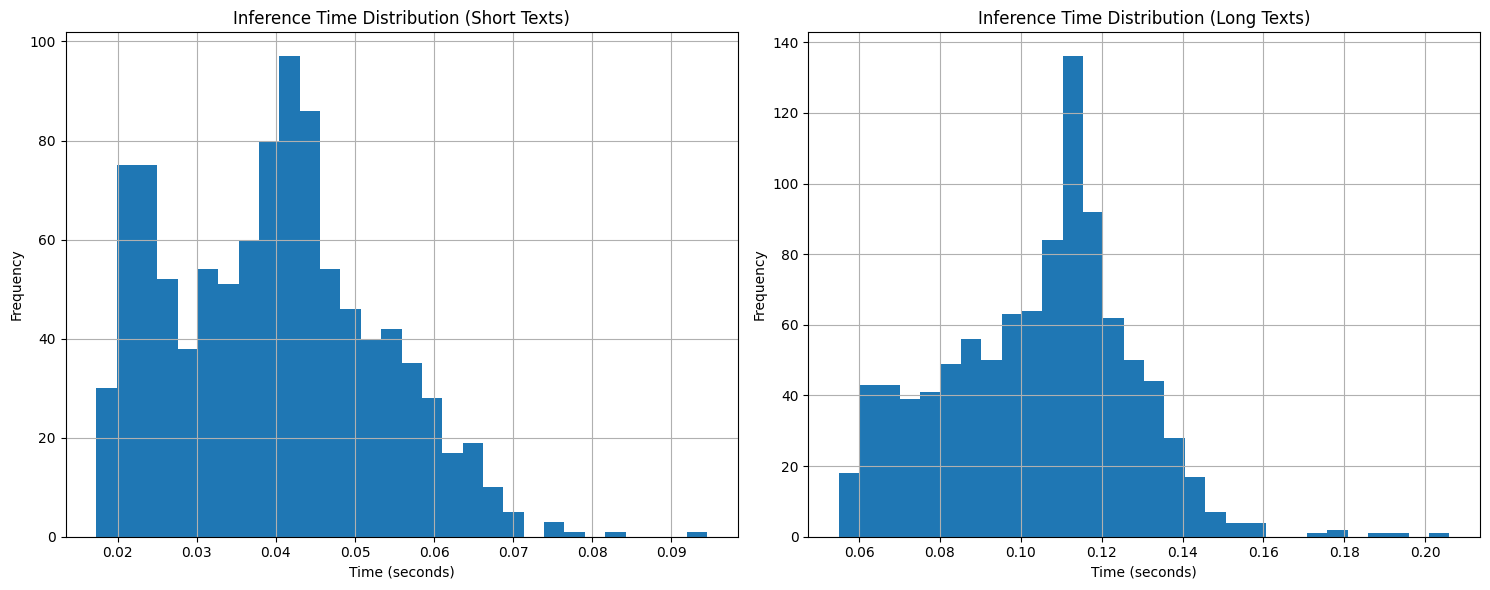

In [ ]:
(_, (ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(times_50, bins=30)
ax1.set_title('Inference Time Distribution (Short Texts)')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Frequency')
ax1.grid(True)

ax2.hist(times_250, bins=30)
ax2.set_title('Inference Time Distribution (Long Texts)')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Frequency')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Выводим 50-й, 90-й и 99-й перцентили для коротких текстов (50 слов)

percentiles = np.percentile(times_50, [50, 90, 99])
print(f"50th percentile: {percentiles[0]:.4f} seconds")
print(f"90th percentile: {percentiles[1]:.4f} seconds")
print(f"99th percentile: {percentiles[2]:.4f} seconds")

50th percentile: 0.0399 seconds
90th percentile: 0.0575 seconds
99th percentile: 0.0688 seconds


In [ ]:
# Выводим 50-й, 90-й и 99-й перцентили для длинных текстов (250 слов)

percentiles = np.percentile(times_250, [50, 90, 99])
print(f"50th percentile: {percentiles[0]:.4f} seconds")
print(f"90th percentile: {percentiles[1]:.4f} seconds")
print(f"99th percentile: {percentiles[2]:.4f} seconds")

50th percentile: 0.1077 seconds
90th percentile: 0.1315 seconds
99th percentile: 0.1547 seconds


Для текстов небольшой длины время работы и его перцентили укладываются в заданные рамки \
Но если текст большой, то время становится значительным \
Стоит отметить, что эти показатели сильно зависят от железа, на котором они запускались. В данном случае не было использована видео-карта \
Ее применение может уменьшить время инфересна на длинных текстах за счет параллелизма, но будет требовать больше ресурсов

Вторая метрика throughput - количество запросов, которое способен обработать и отдать сервис за 1 секунду \
В отличие от среднего времени выполнения, здесь метрика будет показать способности работать с нагрузкой 

In [ ]:
throughput_short = 1000 / (end_time_short - start_time_short)
throughput_long = 1000 / (end_time_long - start_time_long)

print(f"Throughput (Short Texts): {throughput_short:.4f} per second")
print(f"Throughput (Long Texts): {throughput_long:.4f} per second")

Throughput (Short Texts): 25.1877 per second
Throughput (Long Texts): 9.6318 per second


Опять же видно, что с увелечением длины запроса сильно подает пропускная способность (при учете конкретного используемого железа) \
Насколько это хорошие числа - зависит от целей применения. В небольших масштабах они могут быть приемлемы, особенно для небольших текстов.